In [2]:
import os
import numpy as np
import pandas as pd
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
from statistics import mean

import torch
from torch import nn, optim
from torchvision import datasets, transforms, utils, models
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import torchvision.utils as vutils


plt.rcParams.update({'axes.grid': False})

### step1: Preparing the Data

In [3]:
# first let's check if GPU is availble 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device.type}")

Using device: cuda


In [4]:
IMAGE_SIZE = 64
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Range [-1, 1]
])

class CelebADataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.images = [f for f in os.listdir(folder) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.folder, self.images[idx]))
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label, GANs don't need labels

data_folder = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba/'

dataset = CelebADataset(data_folder, transform=transform)

# to improve speed I increased num_workers from 2 to 4 and added pin_memory=True for faster CPU to GPU transfer 
#and persistent_workers=True to keep workers alive between epochs, avoids restart overhead
trainloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)

print(f"Total images: {len(dataset)}") 

Total images: 202599


Batch shape: torch.Size([128, 3, 64, 64])


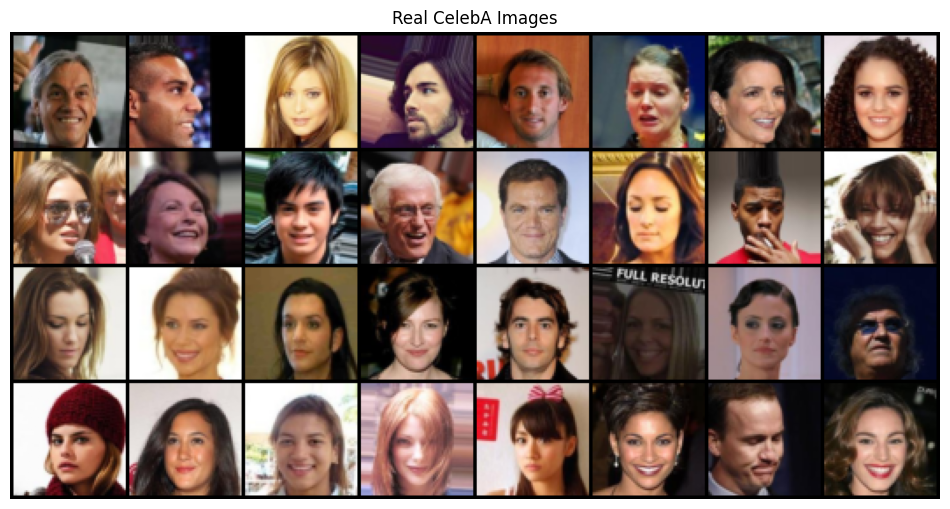

In [5]:
# Grab one batch
images, _ = next(iter(trainloader))
print(f"Batch shape: {images.shape}") 

# Visualize
plt.figure(figsize=(12, 12))
plt.axis("off")
plt.title("Real CelebA Images")
plt.imshow(vutils.make_grid(images[:32], padding=2, normalize=True).permute(1, 2, 0))
plt.show()

### Step2: Create the Generator

The Generator is one of the two neural networks in a GAN. Its job is simple:

Take random noise as input → Output a fake image that looks real

In [6]:
class Generator(nn.Module):
    
    def __init__(self, LATENT_SIZE):
        super(Generator, self).__init__()
        
        self.main = nn.Sequential(
            
            # input dim: [-1, LATENT_SIZE, 1, 1]
            # output size = (1 - 1)*1 - 2*0 + 4

            #This is the upsample layer 
            nn.ConvTranspose2d(LATENT_SIZE, 1024, kernel_size=4, stride=1, padding=0, bias=False),
            #Normalizes the output of the previous layer during training.
            #Very important in GANs — without it training is much harder
            nn.BatchNorm2d(1024),
            #Activation function — adds non-linearity 
            nn.ReLU(inplace=True),

            # output dim: [-1, 1024, 4, 4]
            # output size = (input size - 1)*stride - 2*padding + kernel size
            # (4 - 1)*2 - 2 * 1 + 4 = 4 + 4 = 8

            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            # output dim: [-1, 512, 8, 8]

            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # output dim: [-1, 256, 16, 16]

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            # output dim: [-1, 128, 32, 32]
            
            nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1, bias=False),
            # output dim: [-1, 3, 64, 64]

            nn.Tanh()
        )

    def forward(self, x):
            return self.main(x)
            

In [7]:
LATENT_SIZE = 100

generator = Generator(LATENT_SIZE).to(device)
summary(generator, (LATENT_SIZE, 1, 1));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1           [-1, 1024, 4, 4]       1,638,400
       BatchNorm2d-2           [-1, 1024, 4, 4]           2,048
              ReLU-3           [-1, 1024, 4, 4]               0
   ConvTranspose2d-4            [-1, 512, 8, 8]       8,388,608
       BatchNorm2d-5            [-1, 512, 8, 8]           1,024
              ReLU-6            [-1, 512, 8, 8]               0
   ConvTranspose2d-7          [-1, 256, 16, 16]       2,097,152
       BatchNorm2d-8          [-1, 256, 16, 16]             512
              ReLU-9          [-1, 256, 16, 16]               0
  ConvTranspose2d-10          [-1, 128, 32, 32]         524,288
      BatchNorm2d-11          [-1, 128, 32, 32]             256
             ReLU-12          [-1, 128, 32, 32]               0
  ConvTranspose2d-13            [-1, 3, 64, 64]           6,144
             Tanh-14            [-1, 3,

### Step 3: Creating the Discriminator

The Discriminator is the second neural network in a GAN. Its job is the opposite of the Generator:

Take an image as input → Output a single number: real or fake?

What does it output?
Just a single number between 0 and 1:

1 : "I'm confident this is a real image"

0 : "I'm confident this is a fake image"

0.5 : "I can't tell" ← this is the ideal end goal!

What does the Discriminator network look like?
It's basically the opposite of the Generator — uses regular convolutions to progressively downsample from a full image to a single value
Each downsample step halves the spatial size while doubling the channels — mirror image of the Generator.


In [8]:
class Discriminator(nn.Module):
    
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.main = nn.Sequential(
            
            # input dim: [-1, 3, 64, 64]
            nn.Conv2d(3, 128, kernel_size=4, stride=2, padding=1, bias=False),
            # No BatchNorm on first layer!
            nn.LeakyReLU(0.2, inplace=True),
            
            # output dim: [-1, 128, 32, 32]
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # output dim: [-1, 256, 16, 16]
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # output dim: [-1, 512, 8, 8]
            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            # output dim: [-1, 1024, 4, 4]
            nn.Conv2d(1024, 1, kernel_size=4, stride=1, padding=0, bias=False),

            # output dim: [-1, 1, 1, 1]
            nn.Flatten()
        )

    def forward(self, input):
        return self.main(input)

In [9]:
discriminator = Discriminator().to(device)
summary(discriminator, (3, 64, 64));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 32, 32]           6,144
         LeakyReLU-2          [-1, 128, 32, 32]               0
            Conv2d-3          [-1, 256, 16, 16]         524,288
       BatchNorm2d-4          [-1, 256, 16, 16]             512
         LeakyReLU-5          [-1, 256, 16, 16]               0
            Conv2d-6            [-1, 512, 8, 8]       2,097,152
       BatchNorm2d-7            [-1, 512, 8, 8]           1,024
         LeakyReLU-8            [-1, 512, 8, 8]               0
            Conv2d-9           [-1, 1024, 4, 4]       8,388,608
      BatchNorm2d-10           [-1, 1024, 4, 4]           2,048
        LeakyReLU-11           [-1, 1024, 4, 4]               0
           Conv2d-12              [-1, 1, 1, 1]          16,384
          Flatten-13                    [-1, 1]               0
Total params: 11,036,160
Trainable para

### Initializing our GAN

In [10]:
# Weight Initialization
# GANs are sensitive to starting point of optimization.
# We initialize Conv and ConvTranspose layers with small random values (mean=0, std=0.02)
# and BatchNorm layers with neutral values (weight=1, bias=0).
# This helps stabilize training from the start.

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
        
generator.apply(weights_init)
discriminator.apply(weights_init)

generator = torch.compile(generator)
discriminator = torch.compile(discriminator)

criterion = nn.BCEWithLogitsLoss()

optimizerG = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999)) #the discriminator was learning too fast, so we lowered the learning rate

### Training GAN

We use the following cell to keep track of how a fixed noise (latent vector) is transformed to a generated image in each epoch. We will see that the generations become better and better throughout the epochs:

In [11]:
fixed_noise = torch.randn(64, LATENT_SIZE, 1, 1).to(device)

In [ ]:
#where to save data
os.makedirs('/kaggle/working/generated_images', exist_ok=True)

NUM_EPOCHS = 40

print('Training started:\n')

D_real_epoch, D_fake_epoch, loss_dis_epoch, loss_gen_epoch = [], [], [], []

# Create labels
real_labels = torch.full((BATCH_SIZE,), 0.9, dtype=torch.float).to(device)
fake_labels = torch.full((BATCH_SIZE,), 0.1, dtype=torch.float).to(device)

for epoch in range(NUM_EPOCHS):

    # D_real_iter: list that accumulates the average output of the discriminator 
    # for real images for each batch. High values mean the discriminator is more 
    # confidently classifying real images as real.

    # D_fake_iter: Similar to D_real_iter but for fake images. Low values indicate
    # the descriminator is confidently classifying them as fake. 
    
    # loss_dis_iter: Stores the discriminator loss for each batch. 
    # This is the sum of the loss on real images and the loss on fake images. 
    # Monitoring this helps understand how well the discriminator is 
    # differentiating between real and fake images.

    # loss_gen_iter: Stores the generator loss for each batch. This indicates 
    # how well the generator is fooling the discriminator. 
    
    D_real_iter, D_fake_iter, loss_dis_iter, loss_gen_iter = [], [], [], []
    
    for real_batch, _ in trainloader:

        # STEP 1: train discriminator
        # ==================================
        # Train with real data
        optimizerD.zero_grad()
        
        real_batch = real_batch.to(device)
    
        
        output = discriminator(real_batch).view(-1)
        loss_real = criterion(output, real_labels[:real_batch.shape[0]])
        
        # Iteration book-keeping
        D_real_iter.append(torch.sigmoid(output).mean().item())
        
        # Train with fake data
        noise = torch.randn(real_batch.shape[0], LATENT_SIZE, 1, 1).to(device)
        
        fake_batch = generator(noise)
        
        
        output = discriminator(fake_batch.detach()).view(-1)
        loss_fake = criterion(output, fake_labels[:real_batch.shape[0]])
        
        # Update discriminator weights
        loss_dis = loss_real + loss_fake
        loss_dis.backward()
        optimizerD.step()
        
        # Iteration book-keeping
        loss_dis_iter.append(loss_dis.item()) 
        D_fake_iter.append(torch.sigmoid(output).mean().item())
        
        # STEP 2: train generator
        # ==================================
        optimizerG.zero_grad()

        # Calculate the output with the updated weights of the discriminator
        output = discriminator(fake_batch).view(-1)
        loss_gen = criterion(output, real_labels[:real_batch.shape[0]])
        loss_gen.backward()
        
        # Book-keeping
        loss_gen_iter.append(loss_gen.item())
        
        # Update generator weights and store loss
        optimizerG.step()
        
    print(f"Epoch ({epoch + 1}/{NUM_EPOCHS})\t",
          f"Loss_G: {mean(loss_gen_iter):.4f}",
          f"Loss_D: {mean(loss_dis_iter):.4f}\t",
          f"D_real: {mean(D_real_iter):.4f}",
          f"D_fake: {mean(D_fake_iter):.4f}")
    
    # Epoch book-keeping
    loss_gen_epoch.append(mean(loss_gen_iter))
    loss_dis_epoch.append(mean(loss_dis_iter))
    D_real_epoch.append(mean(D_real_iter))
    D_fake_epoch.append(mean(D_fake_iter))
    
    if (epoch + 1) % 5 == 0:
        # Save generated images
        with torch.no_grad():
            fake_images = generator(fixed_noise).detach().cpu()
        img_grid = vutils.make_grid(fake_images[:64], padding=2, normalize=True)
        vutils.save_image(img_grid, f'/kaggle/working/generated_images/epoch_{epoch+1}.png')
        print(f"  ✓ Generated images saved at epoch {epoch+1}")
    
        # Save checkpoint
        torch.save({
            'epoch': epoch + 1,
            'generator_state': generator.state_dict(),
            'discriminator_state': discriminator.state_dict(),
            'optimizerG_state': optimizerG.state_dict(),
            'optimizerD_state': optimizerD.state_dict(),
            'loss_gen_epoch': loss_gen_epoch,
            'loss_dis_epoch': loss_dis_epoch,
            'D_real_epoch': D_real_epoch,
            'D_fake_epoch': D_fake_epoch,
        }, f'/kaggle/working/checkpoint_epoch_{epoch+1}.pt')
        print(f"  ✓ Checkpoint saved at epoch {epoch+1}")
        
print("\nTraining ended.")

Training started:



W0329 01:11:11.785000 55 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch (1/40)	 Loss_G: 2.3766 Loss_D: 1.4569	 D_real: 0.6114 D_fake: 0.3920


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

epochs_saved = [5, 10, 15, 20, 25, 30, 35, 40]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, epoch in zip(axes.flatten(), epochs_saved):
    img = mpimg.imread(f'/kaggle/working/generated_images/epoch_{epoch}.png')
    ax.imshow(img)
    ax.set_title(f'Epoch {epoch}')
    ax.axis('off')

plt.suptitle('Generator Progress Over Training', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import HTML
import matplotlib.animation as animation

# Load all saved epoch images
epochs_saved = [e for e in range(5, NUM_EPOCHS + 1, 5)]
img_list = []

for epoch in epochs_saved:
    img = mpimg.imread(f'/kaggle/working/generated_images/epoch_{epoch}.png')
    img_list.append(img)

# Animate
fig = plt.figure(figsize=(8, 8))
plt.axis('off')

imgs = [[plt.imshow(img, animated=True), 
         plt.title(f'Epoch {ep}', fontsize=14)] 
        for img, ep in zip(img_list, epochs_saved)]

ani = animation.ArtistAnimation(
    fig, imgs, interval=800, repeat_delay=1000, blit=True
)

HTML(ani.to_jshtml())